In [1]:
import pandas as pd

# Paths
master_path = r"data\processed\ic3_master_crime_panel_2015_2024.csv"
complaints_2022_path = r"data\processed\2022_complaints_raw.csv"

# Load files
master = pd.read_csv(master_path)
raw_2022 = pd.read_csv(complaints_2022_path, header=1)

# Clean column names
master.columns = [str(col).strip() for col in master.columns]
raw_2022.columns = [str(col).strip() for col in raw_2022.columns]

# Clean crime type text
master["Crime Type"] = (
    master["Crime Type"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

raw_2022["Crime Type"] = (
    raw_2022["Crime Type"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("*", "", regex=False)
)

# Keep only the 2022 complaint count column
raw_2022 = raw_2022[["Crime Type", "2022"]].copy()

# Standardise names so they match the master file
name_map = {
    "BEC": "BEC/EAC",
    "Confidence Fraud/Romance": "Confidence/Romance Fraud",
    "Overpayment": "419/Overpayment",
    "Real Estate": "Real Estate/Rental",
    "IPR/Copyright and Counterfeit": "IPR/Copyright/Counterfeit",
    "Lottery/Sweepstakes/Inheritance": "Lottery/Sweepstakes",
    "Phishing": "Phishing/Vishing/Smishing",
    "Credit Card/Check Fraud": "Credit Card/Check Fraud",
    "Data Breach": "Data Breach",
    "Harassment/Stalking": "Harassment/Stalking",
    "Threats of Violence": "Threats of Violence",
    "Personal Data Breach": "Personal Data Breach",
    "Non-Payment/Non-Delivery": "Non-Payment/Non-Delivery"
}

raw_2022["Crime Type"] = raw_2022["Crime Type"].replace(name_map)

# Convert 2022 counts to numeric
raw_2022["2022 Victim Count"] = (
    raw_2022["2022"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+)", expand=False)
)

raw_2022["2022 Victim Count"] = pd.to_numeric(raw_2022["2022 Victim Count"], errors="coerce")

# Keep only the columns needed for merge
raw_2022 = raw_2022[["Crime Type", "2022 Victim Count"]]

# Remove old column if it already exists
master = master.drop(columns=["2022 Victim Count"], errors="ignore")

# Merge 2022 victim counts into master file
master = master.merge(raw_2022, on="Crime Type", how="left")

# Reorder columns so 2022 Victim Count sits in the right place
cols = master.columns.tolist()

if "2021 Victim Count" in cols and "2022 Victim Count" in cols:
    cols.remove("2022 Victim Count")
    insert_at = cols.index("2021 Victim Count") + 1
    cols.insert(insert_at, "2022 Victim Count")
    master = master[cols]

# Save updated master file
master.to_csv(master_path, index=False)

# Optional check
print("Updated file saved:")
print(master_path)
print("\nRows with 2022 Victim Count:")
print(master[["Crime Type", "2022 Victim Count"]].dropna().head(20))

# Optional check for names that did not match
unmatched = raw_2022.loc[~raw_2022["Crime Type"].isin(master["Crime Type"]), "Crime Type"].drop_duplicates()
print("\nUnmatched crime types:")
print(unmatched.tolist())

Updated file saved:
data\processed\ic3_master_crime_panel_2015_2024.csv

Rows with 2022 Victim Count:
                   Crime Type  2022 Victim Count
0             419/Overpayment             6183.0
1                Advanced Fee            11264.0
3                     BEC/EAC            21832.0
4                      Botnet              568.0
7    Confidence/Romance Fraud            19021.0
8     Credit Card/Check Fraud            22985.0
9     Crimes Against Children             2587.0
11                Data Breach             2795.0
14                 Employment            14946.0
15                  Extortion            39416.0
17   Government Impersonation            11554.0
19        Harassment/Stalking            11779.0
21  IPR/Copyright/Counterfeit             2183.0
22             Identity Theft            27922.0
23                 Investment            30529.0
28   Non-Payment/Non-Delivery            51679.0
29                      Other             9966.0
30       Persona

# Note:
# Some crime types could not be matched due to naming inconsistencies.
# These are excluded from further analysis to maintain consistency.

In [2]:
print(master.columns.tolist())
print(master[["Crime Type", "2022 Victim Count"]].dropna().head(30))

['Crime Type', '2015 Victim Count', '2016 Victim Count', '2017 Victim Count', '2018 Victim Count', '2019 Victim Count', '2020 Victim Count', '2021 Victim Count', '2022 Victim Count', '2023 Victim Count', '2024 Victim Count', '2015 Loss ($)', '2016 Loss ($)', '2017 Loss ($)', '2018 Loss ($)', '2019 Loss ($)', '2020 Loss ($)', '2021 Loss ($)', '2022 Loss ($)', '2023 Loss ($)', '2024 Loss ($)']
                   Crime Type  2022 Victim Count
0             419/Overpayment             6183.0
1                Advanced Fee            11264.0
3                     BEC/EAC            21832.0
4                      Botnet              568.0
7    Confidence/Romance Fraud            19021.0
8     Credit Card/Check Fraud            22985.0
9     Crimes Against Children             2587.0
11                Data Breach             2795.0
14                 Employment            14946.0
15                  Extortion            39416.0
17   Government Impersonation            11554.0
19        Harassm

In [3]:
print(master[master["2022 Victim Count"].notna()][["Crime Type", "2021 Victim Count", "2022 Victim Count", "2023 Victim Count", "2024 Victim Count"]].head(40))

                   Crime Type  2021 Victim Count  2022 Victim Count  \
0             419/Overpayment             6108.0             6183.0   
1                Advanced Fee            11034.0            11264.0   
3                     BEC/EAC            19954.0            21832.0   
4                      Botnet                NaN              568.0   
7    Confidence/Romance Fraud            24299.0            19021.0   
8     Credit Card/Check Fraud            16750.0            22985.0   
9     Crimes Against Children             2167.0             2587.0   
11                Data Breach             1287.0             2795.0   
14                 Employment            15253.0            14946.0   
15                  Extortion            39360.0            39416.0   
17   Government Impersonation            11335.0            11554.0   
19        Harassment/Stalking                NaN            11779.0   
21  IPR/Copyright/Counterfeit             4270.0             2183.0   
22    

In [4]:
print(master[master["Crime Type"].str.contains("Threat|Harass|SIM|BEC|Romance|Overpayment|Phishing", case=False, na=False)][["Crime Type"]])


                   Crime Type
0             419/Overpayment
3                     BEC/EAC
7    Confidence/Romance Fraud
19        Harassment/Stalking
31          Phishing/Spoofing
32  Phishing/Vishing/Smishing
36                   SIM Swap
39        Threats of Violence


In [5]:
import pandas as pd

master_path = r"data\processed\ic3_master_crime_panel_2015_2024.csv"
df = pd.read_csv(master_path)

df.columns = [str(col).strip() for col in df.columns]
df["Crime Type"] = df["Crime Type"].astype(str).str.strip()

harmonised_map = {
    "BEC/EAC": "BEC/EAC",
    "419/Overpayment": "419/Overpayment",
    "Confidence/Romance Fraud": "Confidence/Romance Fraud",
    "Phishing/Vishing/Smishing": "Phishing",
    "Phishing/Spoofing": "Phishing",
    "Spoofing": "Phishing",
    "SIM Swap": "SIM Swap",
    "Harassment/Stalking": "Harassment/Threats",
    "Threats of Violence": "Harassment/Threats"
}

df["Crime Type Harmonised"] = df["Crime Type"].replace(harmonised_map)

print(df[["Crime Type", "Crime Type Harmonised"]].drop_duplicates().sort_values("Crime Type"))


                         Crime Type            Crime Type Harmonised
0                   419/Overpayment                  419/Overpayment
1                      Advanced Fee                     Advanced Fee
2                           Auction                          Auction
3                           BEC/EAC                          BEC/EAC
4                            Botnet                           Botnet
5                           Charity                          Charity
6                      Civil Matter                     Civil Matter
7          Confidence/Romance Fraud         Confidence/Romance Fraud
8           Credit Card/Check Fraud          Credit Card/Check Fraud
9           Crimes Against Children          Crimes Against Children
10                  Criminal Forums                  Criminal Forums
11                      Data Breach                      Data Breach
12                Denial of Service                Denial of Service
13           Denial of Service/TDo

In [8]:
import re
import pandas as pd

master_path = r"data\processed\ic3_master_crime_panel_2015_2024.csv"
df = pd.read_csv(master_path)

df.columns = [str(col).strip() for col in df.columns]
df["Crime Type"] = df["Crime Type"].astype(str).str.strip()

harmonised_map = {
    "Phishing/Vishing/Smishing": "Phishing",
    "Phishing/Spoofing": "Phishing",
    "Spoofing": "Phishing",
    "Harassment/Stalking": "Harassment/Threats",
    "Threats of Violence": "Harassment/Threats"
}

df["Crime Type Harmonised"] = df["Crime Type"].replace(harmonised_map)

count_cols = [col for col in df.columns if re.fullmatch(r"\d{4} Victim Count", col)]
loss_cols = [col for col in df.columns if re.fullmatch(r"\d{4} Loss \(\$\)", col)]

counts_long = df.melt(
    id_vars=["Crime Type", "Crime Type Harmonised"],
    value_vars=count_cols,
    var_name="Measure",
    value_name="Victim Count"
)

counts_long["Year"] = counts_long["Measure"].str.extract(r"(\d{4})").astype(int)
counts_long = counts_long.drop(columns="Measure")

losses_long = df.melt(
    id_vars=["Crime Type", "Crime Type Harmonised"],
    value_vars=loss_cols,
    var_name="Measure",
    value_name="Loss $"
)

losses_long["Year"] = losses_long["Measure"].str.extract(r"(\d{4})").astype(int)
losses_long = losses_long.drop(columns="Measure")

panel_long = pd.merge(
    counts_long,
    losses_long,
    on=["Crime Type", "Crime Type Harmonised", "Year"],
    how="outer"
)

panel_harmonised = (
    panel_long
    .groupby(["Crime Type Harmonised", "Year"], as_index=False)
    .agg({
        "Victim Count": "sum",
        "Loss $": "sum"
    })
    .sort_values(["Crime Type Harmonised", "Year"])
)

panel_long.to_csv(
    r"data\processed\ic3_panel_long_raw_labels.csv",
    index=False
)

panel_harmonised.to_csv(
    r"data\processed\ic3_panel_long_harmonised.csv",
    index=False
)

print(panel_harmonised.head(30))
print("\nShape:", panel_harmonised.shape)

   Crime Type Harmonised  Year  Victim Count       Loss $
0        419/Overpayment  2015       30855.0   49217119.0
1        419/Overpayment  2016       25716.0   56004836.0
2        419/Overpayment  2017       23135.0   53450830.0
3        419/Overpayment  2018       15512.0   53225507.0
4        419/Overpayment  2019       15395.0   55820212.0
5        419/Overpayment  2020       10988.0   51039922.0
6        419/Overpayment  2021        6108.0   33407671.0
7        419/Overpayment  2022        6183.0   38335772.0
8        419/Overpayment  2023        4144.0   27955195.0
9        419/Overpayment  2024        2705.0   21452521.0
10          Advanced Fee  2015       16445.0   50721226.0
11          Advanced Fee  2016       15075.0   59139152.0
12          Advanced Fee  2017       16368.0   57861324.0
13          Advanced Fee  2018       16362.0   92271682.0
14          Advanced Fee  2019       14607.0  100602297.0
15          Advanced Fee  2020       13020.0   83215405.0
16          Ad

In [9]:
import matplotlib.pyplot as plt

complaint_cols = [c for c in master.columns if "Victim Count" in c]
loss_cols       = [c for c in master.columns if "Loss ($)" in c]

yearly_totals = []

for c in complaint_cols:
    year = int(c.split()[0])
    yearly_totals.append({"Year": year, "Metric": "complaints",
                           "Total": master[c].sum(skipna=True)})

for c in loss_cols:
    year = int(c.split()[0])
    yearly_totals.append({"Year": year, "Metric": "losses",
                           "Total": master[c].sum(skipna=True)})

yearly_totals_df = (
    pd.DataFrame(yearly_totals)
      .sort_values(["Year", "Metric"])
      .reset_index(drop=True)
)

yearly_totals_df

,Year,Metric,Total
0,2015,complaints,3.687620e+05
1,2015,losses,1.240162e+09
2,2016,complaints,3.681940e+05
3,2016,losses,1.443696e+09
4,2017,complaints,3.545670e+05
5,2017,losses,1.720592e+09
6,2018,complaints,4.237430e+05
7,2018,losses,3.415816e+09
8,2019,complaints,5.011190e+05
9,2019,losses,4.384107e+09


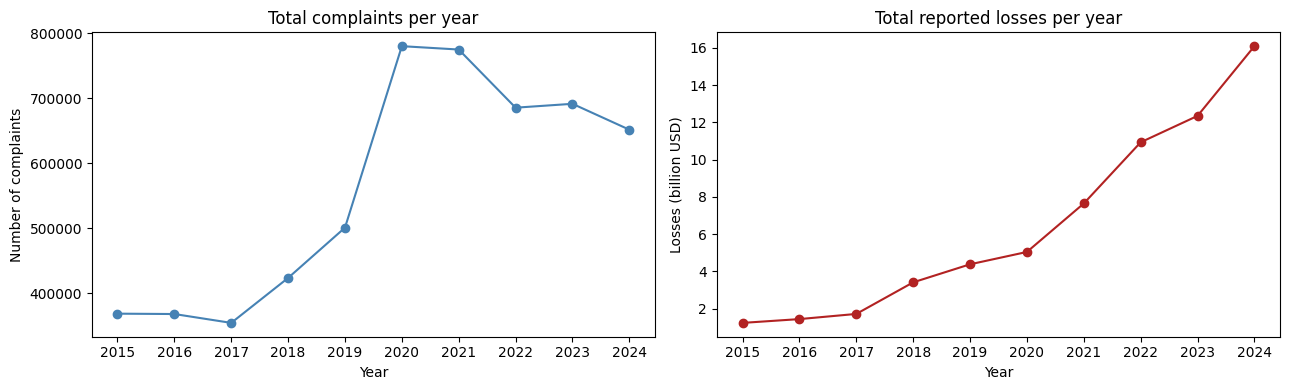

In [10]:
totals_wide = yearly_totals_df.pivot(
    index="Year", columns="Metric", values="Total"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(totals_wide.index, totals_wide["complaints"], marker="o", color="steelblue")
axes[0].set_title("Total complaints per year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of complaints")
axes[0].set_xticks(totals_wide.index)

axes[1].plot(totals_wide.index, totals_wide["losses"] / 1e9, marker="o", color="firebrick")
axes[1].set_title("Total reported losses per year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Losses (billion USD)")
axes[1].set_xticks(totals_wide.index)

plt.tight_layout()
plt.savefig("fig_yearly_trends.png", dpi=150)
plt.show()

In [11]:
# Overall percentage change from 2015 to 2024
complaint_growth = (
    (totals_wide["complaints"].iloc[-1] - totals_wide["complaints"].iloc[0])
    / totals_wide["complaints"].iloc[0] * 100
)

loss_growth = (
    (totals_wide["losses"].iloc[-1] - totals_wide["losses"].iloc[0])
    / totals_wide["losses"].iloc[0] * 100
)

print(f"Complaint volume change 2015–2024: {complaint_growth:.1f}%")
print(f"Reported losses change  2015–2024: {loss_growth:.1f}%")

Complaint volume change 2015–2024: 76.8%
Reported losses change  2015–2024: 1197.3%


In [21]:
top_complaints_2024 = (
    panel_harmonised[panel_harmonised["Year"] == 2024]
    .nlargest(10, "Victim Count")[["Crime Type Harmonised", "Victim Count"]]
    .sort_values("Victim Count")
    .head(10)
    .reset_index(drop=True)
)

top_complaints_2024

,Crime Type Harmonised,Victim Count
0,Confidence/Romance Fraud,17910.0
1,Employment,20044.0
2,Identity Theft,21403.0
3,BEC/EAC,21442.0
4,Tech Support,36002.0
5,Investment,47919.0
6,Non-Payment/Non-Delivery,49572.0
7,Personal Data Breach,64882.0
8,Extortion,86415.0
9,Phishing,193407.0


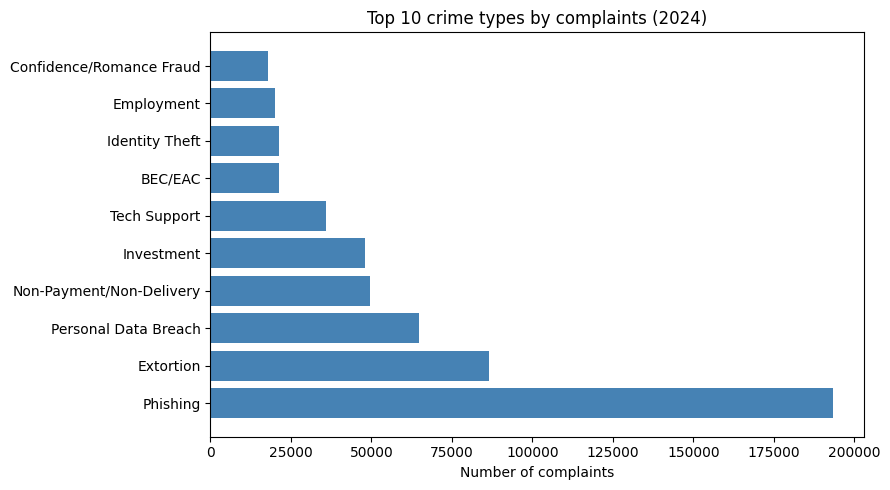

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    top_complaints_2024["Crime Type Harmonised"][::-1],
    top_complaints_2024["Victim Count"][::-1],
    color="steelblue"
)
ax.set_xlabel("Number of complaints")
ax.set_title("Top 10 crime types by complaints (2024)")

plt.tight_layout()
plt.savefig("fig_top10_complaints_2024.png", dpi=150)
plt.show()

In [24]:
top_losses_2024 = (
    master[["Crime Type", "2024 Loss ($)"]]
    .dropna(subset=["2024 Loss ($)"])
    .sort_values("2024 Loss ($)", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_losses_2024["2024 Loss ($ bn)"] = top_losses_2024["2024 Loss ($)"] / 1e9

top_losses_2024

,Crime Type,2024 Loss ($),2024 Loss ($ bn)
0,Investment,6.570640e+09,6.570640
1,BEC/EAC,2.770151e+09,2.770151
2,Tech Support,1.464756e+09,1.464756
3,Personal Data Breach,1.453296e+09,1.453296
4,Non-Payment/Non-Delivery,7.854369e+08,0.785437
5,Confidence/Romance Fraud,6.720091e+08,0.672009
6,Government Impersonation,4.056241e+08,0.405624
7,Data Breach,3.648558e+08,0.364856
8,Other,2.802783e+08,0.280278
9,Employment,2.642233e+08,0.264223


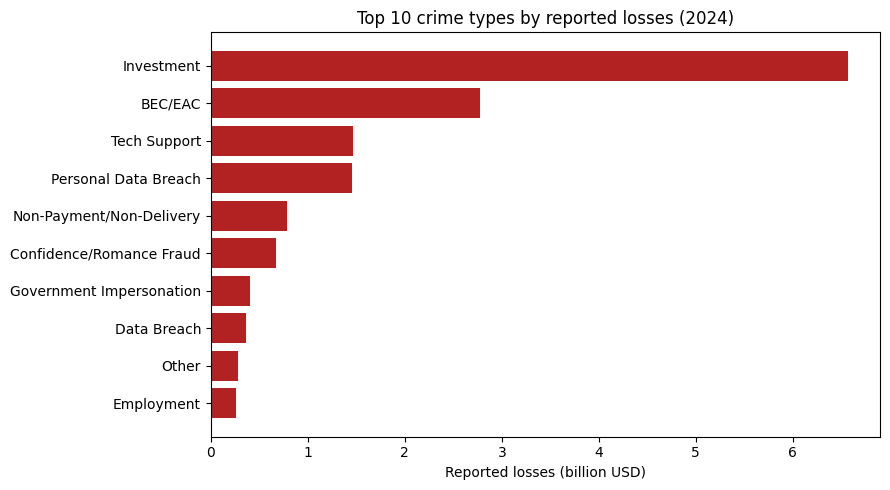

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    top_losses_2024["Crime Type"][::-1],
    top_losses_2024["2024 Loss ($ bn)"][::-1],
    color="firebrick"
)
ax.set_xlabel("Reported losses (billion USD)")
ax.set_title("Top 10 crime types by reported losses (2024)")

plt.tight_layout()
plt.savefig("fig_top10_losses_2024.png", dpi=150)
plt.show()

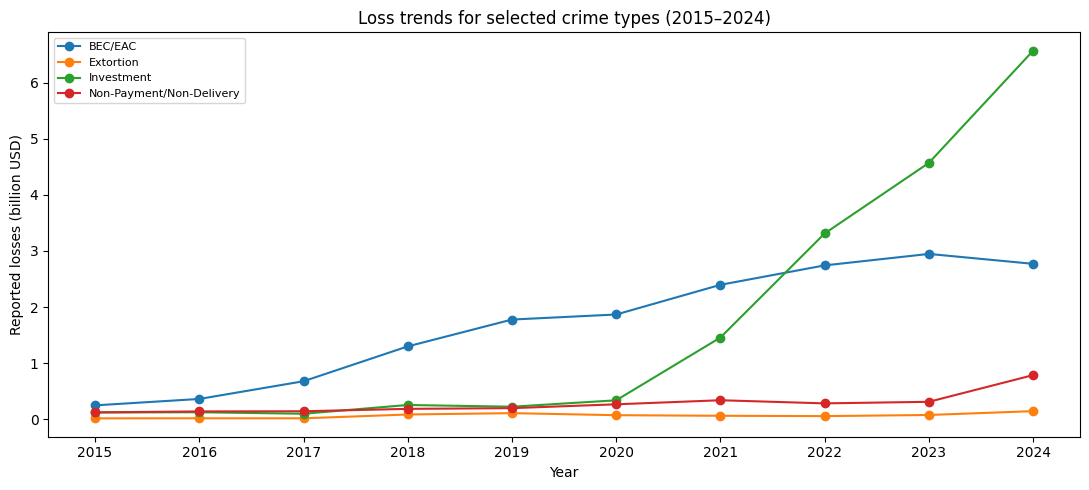

In [26]:
trend_losses_df = (
    master[master["Crime Type"].isin(key_crimes)][["Crime Type"] + loss_cols]
    .melt(id_vars="Crime Type", var_name="Year", value_name="Loss ($)")
)

trend_losses_df["Year"] = trend_losses_df["Year"].str.extract(r"(\d{4})").astype(int)

fig, ax = plt.subplots(figsize=(11, 5))

for crime, group in trend_losses_df.groupby("Crime Type"):
    group_sorted = group.sort_values("Year")
    ax.plot(group_sorted["Year"], group_sorted["Loss ($)"] / 1e9,
            marker="o", label=crime)

ax.set_title("Loss trends for selected crime types (2015–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Reported losses (billion USD)")
ax.legend(fontsize=8)
ax.set_xticks(range(2015, 2025))

plt.tight_layout()
plt.savefig("fig_trend_key_crimes_losses.png", dpi=150)
plt.show()

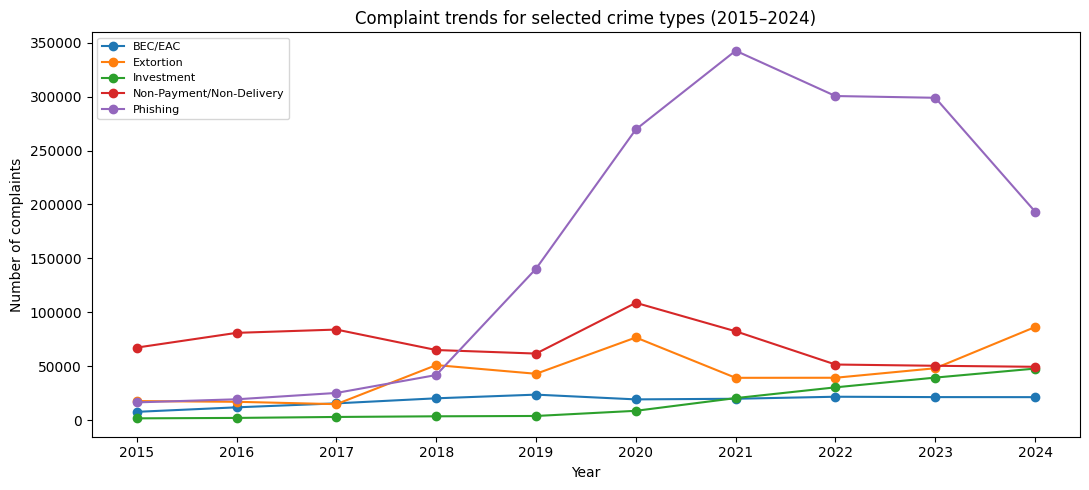

In [27]:
# Use the harmonised long panel already built above
key_crimes = [
    "Phishing",
    "Non-Payment/Non-Delivery",
    "BEC/EAC",
    "Investment",
    "Extortion",
]

trend_complaints = panel_harmonised[
    panel_harmonised["Crime Type Harmonised"].isin(key_crimes)
].copy()

fig, ax = plt.subplots(figsize=(11, 5))

for crime, group in trend_complaints.groupby("Crime Type Harmonised"):
    g = group.sort_values("Year")
    ax.plot(g["Year"], g["Victim Count"], marker="o", label=crime)

ax.set_title("Complaint trends for selected crime types (2015–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of complaints")
ax.legend(fontsize=8)
ax.set_xticks(range(2015, 2025))
plt.tight_layout()
plt.savefig("fig_trend_complaints.png", dpi=150)
plt.show()


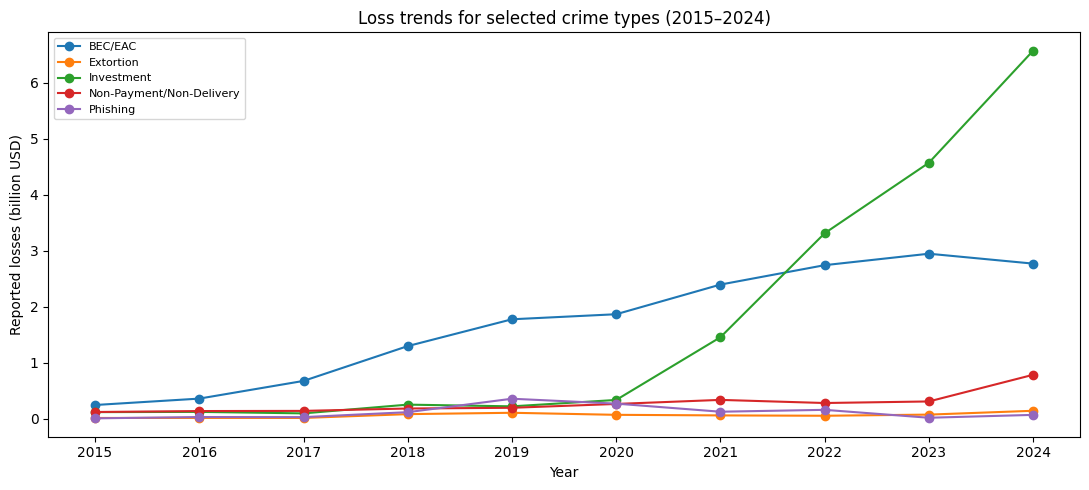

In [29]:
fig, ax = plt.subplots(figsize=(11, 5))

for crime, group in trend_complaints.groupby("Crime Type Harmonised"):
    g = group.sort_values("Year")
    ax.plot(g["Year"], g["Loss $"] / 1e9, marker="o", label=crime)

ax.set_title("Loss trends for selected crime types (2015–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Reported losses (billion USD)")
ax.legend(fontsize=8)
ax.set_xticks(range(2015, 2025))
plt.tight_layout()
plt.savefig("fig_trend_losses.png", dpi=150)
plt.show()
